In [2]:
!pip install pandas matplotlib seaborn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
file_path = r"C:\Users\DELL\Downloads\Unemployment in India.csv"

df = pd.read_csv(file_path)

In [5]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
df.shape

(768, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [8]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [9]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [10]:
df.columns = df.columns.str.strip()

df["Date"] = df["Date"].str.strip()
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [11]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [12]:
df = df.dropna()
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [13]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

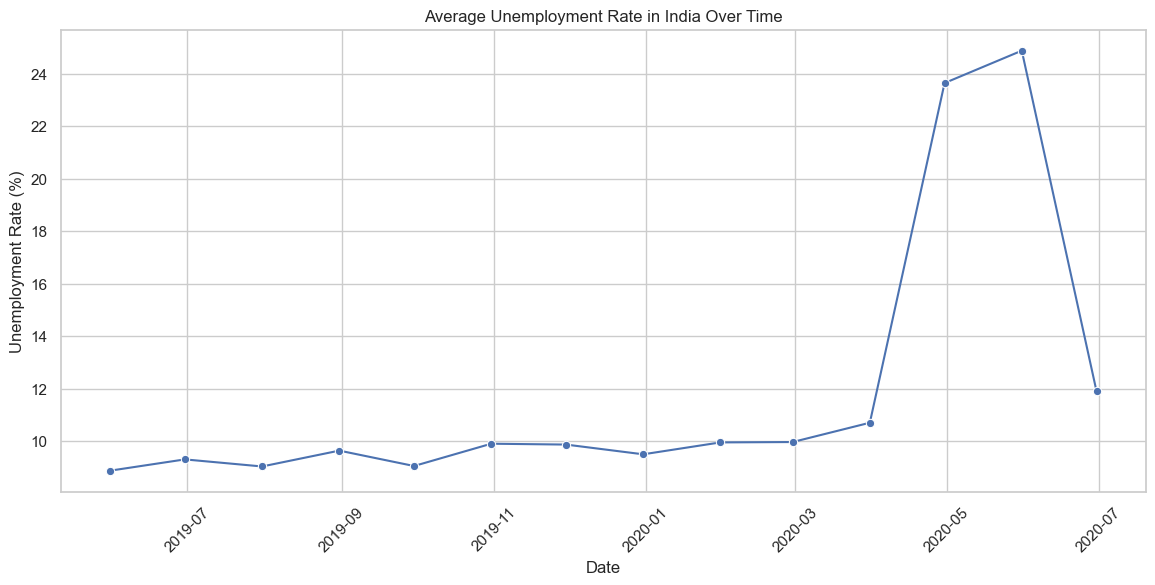

In [14]:
monthly_unemployment = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_unemployment,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    marker="o"
)

plt.title("Average Unemployment Rate in India Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [15]:
def covid_period(date):
    if date < pd.to_datetime("2020-03-01"):
        return "Pre-Covid"
    elif date <= pd.to_datetime("2020-06-30"):
        return "Covid Period"
    else:
        return "Post-Covid"

df["Covid_Period"] = df["Date"].apply(covid_period)

covid_analysis = df.groupby("Covid_Period")["Estimated Unemployment Rate (%)"].mean().reset_index()

covid_analysis

,Covid_Period,Estimated Unemployment Rate (%)
0,Covid Period,17.774363
1,Pre-Covid,9.509534


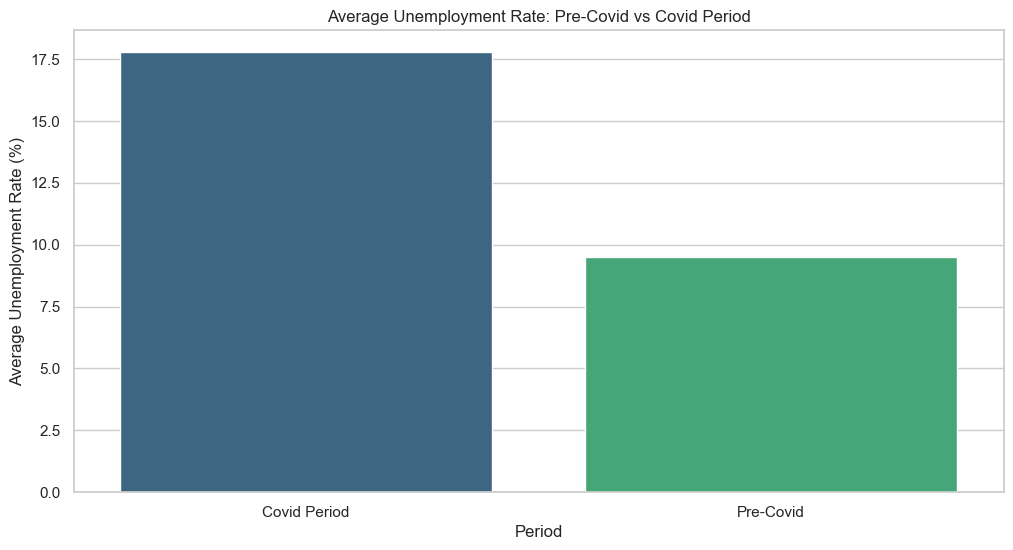

In [16]:
sns.barplot(
    data=covid_analysis,
    x="Covid_Period",
    y="Estimated Unemployment Rate (%)",
    hue="Covid_Period",
    palette="viridis",
    legend=False
)

plt.title("Average Unemployment Rate: Pre-Covid vs Covid Period")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

In [17]:
region_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

region_unemployment.head(10)

,Region,Estimated Unemployment Rate (%)
0,Tripura,28.350357
1,Haryana,26.283214
2,Jharkhand,20.585000
3,Bihar,18.918214
4,Himachal Pradesh,18.540357
5,Delhi,16.495357
6,Jammu & Kashmir,16.188571
7,Chandigarh,15.991667
8,Rajasthan,14.058214
9,Uttar Pradesh,12.551429


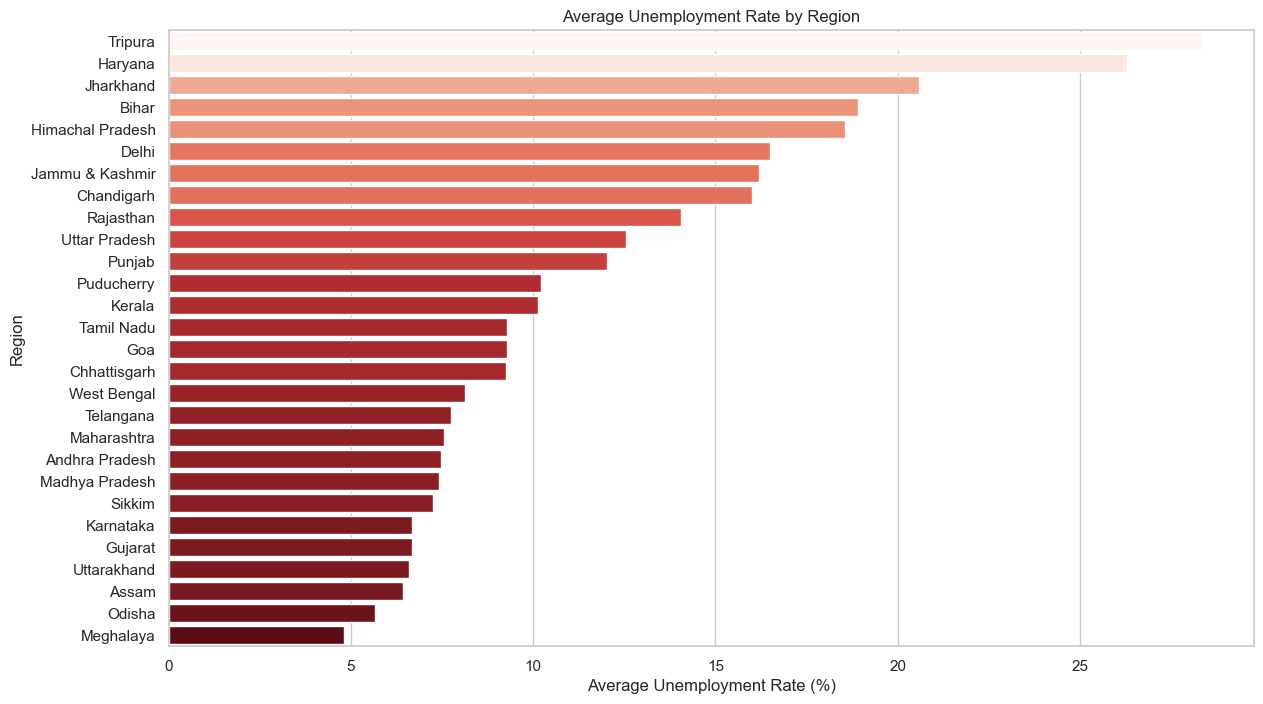

In [18]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=region_unemployment,
    x="Estimated Unemployment Rate (%)",
    y="Region",
    hue="Estimated Unemployment Rate (%)",
    palette="Reds_r",
    legend=False
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.show()

In [19]:
covid_df = df[df["Covid_Period"] == "Covid Period"]

top_covid_regions = (
    covid_df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_covid_regions

,Region,Estimated Unemployment Rate (%)
0,Puducherry,38.95500
1,Jharkhand,36.34875
2,Haryana,34.65250
3,Bihar,31.63125
4,Tripura,26.70250
5,Tamil Nadu,25.40375
6,Delhi,22.15750
7,Kerala,17.95250
8,Uttar Pradesh,17.38250
9,Rajasthan,17.31125


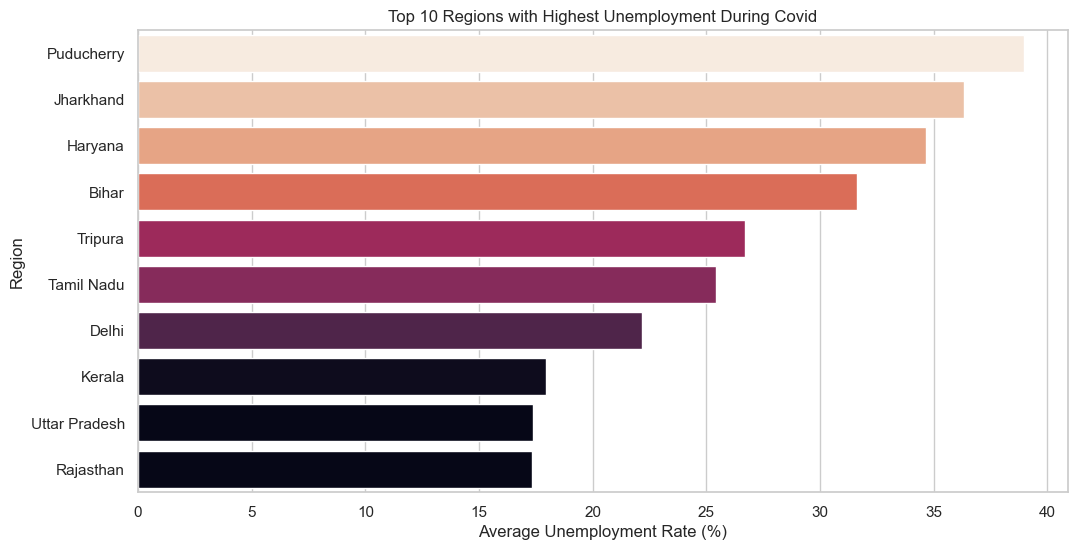

In [20]:
sns.barplot(
    data=top_covid_regions,
    x="Estimated Unemployment Rate (%)",
    y="Region",
    hue="Estimated Unemployment Rate (%)",
    palette="rocket",
    legend=False
)

plt.title("Top 10 Regions with Highest Unemployment During Covid")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.show()

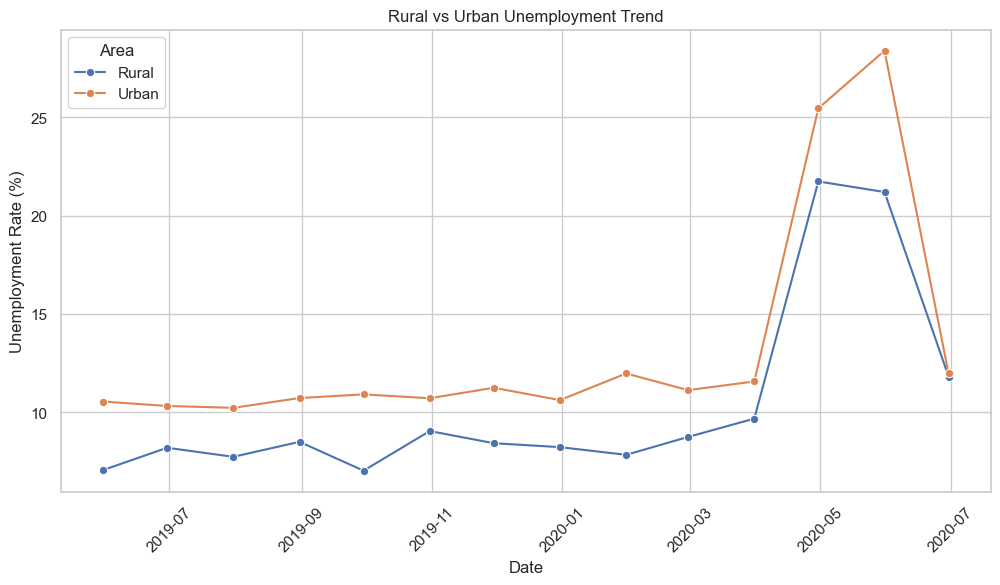

In [21]:
area_analysis = df.groupby(["Date", "Area"])["Estimated Unemployment Rate (%)"].mean().reset_index()

sns.lineplot(
    data=area_analysis,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Area",
    marker="o"
)

plt.title("Rural vs Urban Unemployment Trend")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

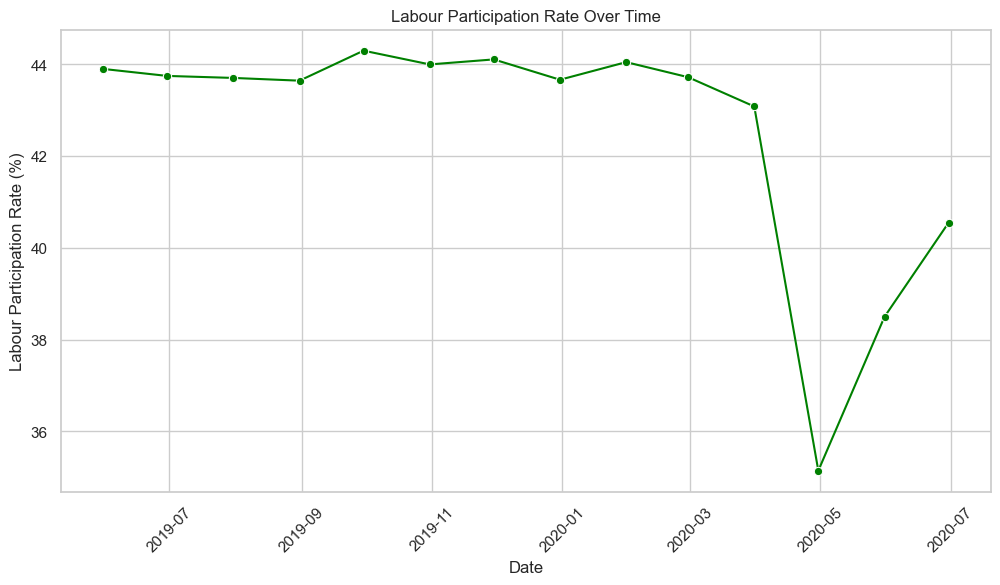

In [22]:
labour_trend = df.groupby("Date")["Estimated Labour Participation Rate (%)"].mean().reset_index()

sns.lineplot(
    data=labour_trend,
    x="Date",
    y="Estimated Labour Participation Rate (%)",
    marker="o",
    color="green"
)

plt.title("Labour Participation Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Labour Participation Rate (%)")
plt.xticks(rotation=45)
plt.show()

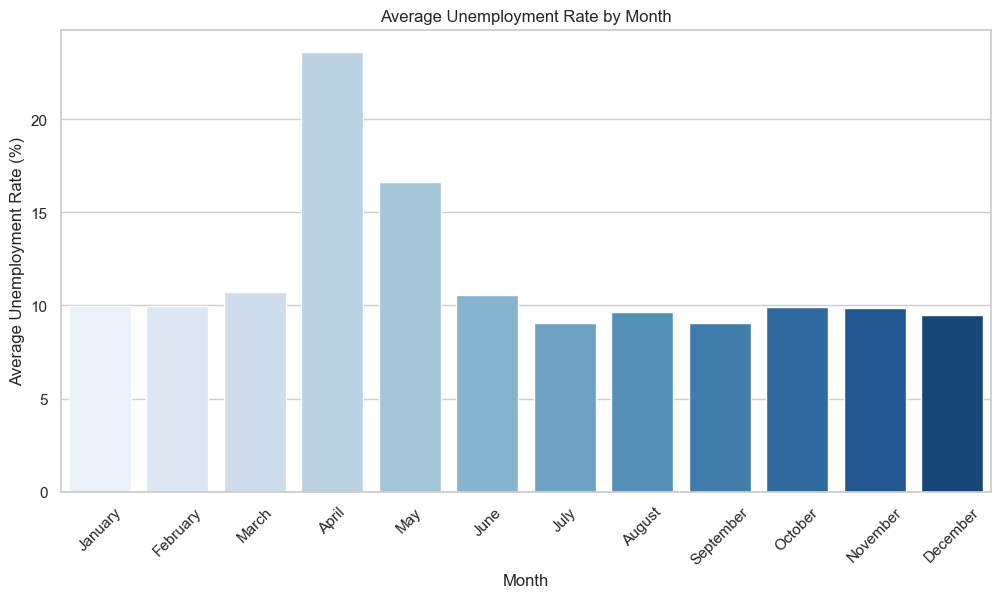

In [23]:
monthly_pattern = df.groupby("Month_Name")["Estimated Unemployment Rate (%)"].mean().reset_index()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_pattern["Month_Name"] = pd.Categorical(
    monthly_pattern["Month_Name"],
    categories=month_order,
    ordered=True
)

monthly_pattern = monthly_pattern.sort_values("Month_Name")

sns.barplot(
    data=monthly_pattern,
    x="Month_Name",
    y="Estimated Unemployment Rate (%)",
    hue="Month_Name",
    palette="Blues",
    legend=False
)

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [24]:
corr = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

corr

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


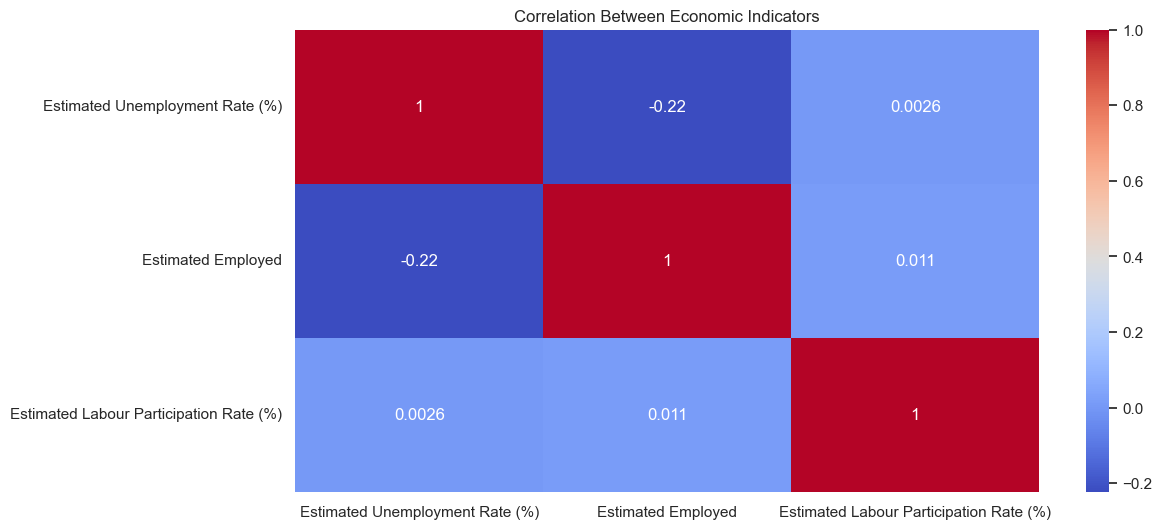

In [25]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Economic Indicators")
plt.show()

In [26]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name,Covid_Period
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May,Pre-Covid
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,June,Pre-Covid
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,July,Pre-Covid
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,August,Pre-Covid
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,September,Pre-Covid


In [27]:
df.to_csv("Cleaned_Data.csv",index=False)